In [1]:
!pip install yfinance

In [13]:
# --- BLOCK 1: NVIDIA Data Acquisition ---
import yfinance as yf
import pandas as pd
import numpy as np

# Configuration
TICKER = "NVDA"
TRAIN_YEARS = 4

print(f"--- FETCHING CONTINUOUS DATA FOR {TICKER} ---")
# Dynamic Start Date: Last 4 years from TODAY
start_date = (pd.Timestamp.now() - pd.DateOffset(years=TRAIN_YEARS + 1)).strftime('%Y-%m-%d')
df = yf.download(TICKER, start=start_date, progress=False)

if len(df) == 0:
    print("❌ ERROR: No data fetched.")
else:
    print(f"✅ Data fetched: {len(df)} rows.")

    # --- FEATURE ENGINEERING (Research Based) ---
    # NVIDIA is volatile, so we add Volatility features alongside MAs
    df['MA10'] = df['Close'].rolling(window=10).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA50'] = df['Close'].rolling(window=50).mean()

    # Volatility: Standard deviation of last 20 days
    df['Volatility'] = df['Close'].rolling(window=20).std()

    # Drop NaNs
    df_clean = df.dropna()

    print(f"✅ Features Created: MA10, MA20, MA50, Volatility")
    print(f"✅ Data Cleaned. Final Shape: {df_clean.shape}")
    print("Sample of latest data:")
    print(df_clean[['Close', 'MA10', 'Volatility']].tail())


--- FETCHING CONTINUOUS DATA FOR NVDA ---


/tmp/ipython-input-2480198075.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=start_date, progress=False)


✅ Data fetched: 1256 rows.
✅ Features Created: MA10, MA20, MA50, Volatility
✅ Data Cleaned. Final Shape: (1207, 9)
Sample of latest data:
Price            Close        MA10 Volatility
Ticker            NVDA                       
Date                                         
2026-01-12  184.940002  187.042000   5.909863
2026-01-13  185.809998  186.800999   5.539573
2026-01-14  183.139999  186.361000   5.212737
2026-01-15  187.050003  186.416000   4.960953
2026-01-16  188.039993  186.334999   3.676392


In [14]:
# --- BLOCK 2: NVIDIA Preprocessing ---
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Configuration
LOOKBACK = 60
# Note: Added 'Volatility' to features
FEATURE_COLS = ['Close', 'MA10', 'MA20', 'MA50', 'Volume', 'Volatility']

print("--- PREPROCESSING DATA ---")

scaler_features = MinMaxScaler(feature_range=(0, 1))
scaler_target = MinMaxScaler(feature_range=(0, 1))

# Extract Data
data_features = df_clean[FEATURE_COLS].values
# Handle yfinance multi-index if present
if data_features.ndim > 2:
    data_features = data_features.reshape(data_features.shape[0], -1)

data_target = df_clean[['Close']].values

# Scale
scaled_features = scaler_features.fit_transform(data_features)
scaled_target = scaler_target.fit_transform(data_target)

# Create Sequences
X, y = [], []
for i in range(LOOKBACK, len(scaled_features)):
    X.append(scaled_features[i-LOOKBACK:i])
    y.append(scaled_target[i])

X, y = np.array(X), np.array(y)

# Train/Test Split (90/10)
split_idx = int(len(X) * 0.90)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"✅ Data Processed.")
print(f"   X Shape: {X.shape} (Note: 6 Features now)")
print(f"   Training Samples: {len(X_train)}")
print(f"   Testing Samples:  {len(X_test)}")


--- PREPROCESSING DATA ---
✅ Data Processed.
   X Shape: (1147, 60, 6) (Note: 6 Features now)
   Training Samples: 1032
   Testing Samples:  115


In [15]:
# --- BLOCK 3: NVIDIA Model Training ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

print("--- BUILDING NVIDIA MODEL ---")

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    # Layer 1: Wider (128 units) for high volatility capture
    LSTM(units=128, return_sequences=True),
    Dropout(0.2),

    # Layer 2: 64 units
    LSTM(units=64, return_sequences=False),
    Dropout(0.2),

    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

print("\n--- TRAINING ---")
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training Complete.")


--- BUILDING NVIDIA MODEL ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,593 (463.25 KB)

 Trainable params: 118,593 (463.25 KB)

 Non-trainable params: 0 (0.00 B)


--- TRAINING ---
Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - loss: 0.0233 - val_loss: 0.0127
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0027 - val_loss: 0.0133
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - loss: 0.0025 - val_loss: 0.0075
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0019 - val_loss: 0.0039
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0022 - val_loss: 0.0044
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0016 - val_loss: 0.0026
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0018 - val_loss: 0.0078
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0018 - val_loss: 0.0020
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0015 - val_loss: 0.0066
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 0.0017 - val_loss: 0.0029
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 12/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3

--- VALIDATING NVIDIA RESULTS ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step

=== 🏆 NVIDIA RESULTS ===
RMSE: $6.71 (Research Benchmark: ~$7.38)
MAE:  $5.10
MAPE: 2.75%
✅ SUCCESS: Research Benchmark Met!


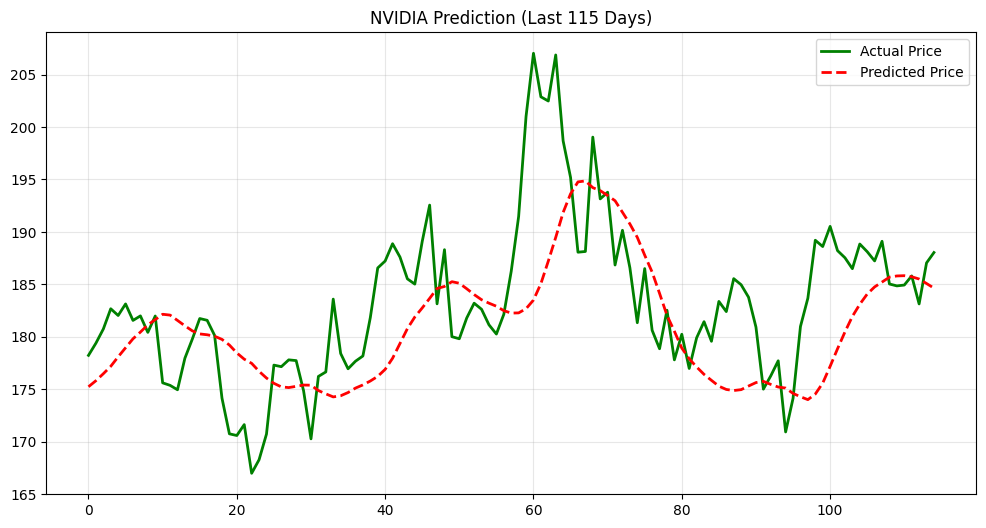


✅ NVIDIA Model & Scalers Saved.


In [16]:
# --- BLOCK 4: NVIDIA Validation ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import math
import matplotlib.pyplot as plt

print("--- VALIDATING NVIDIA RESULTS ---")

# Predict
preds_scaled = model.predict(X_test)

# Inverse Transform
preds_actual = scaler_target.inverse_transform(preds_scaled)
y_test_actual = scaler_target.inverse_transform(y_test)

# Calculate Metrics
rmse = math.sqrt(mean_squared_error(y_test_actual, preds_actual))
mae = mean_absolute_error(y_test_actual, preds_actual)
mape = mean_absolute_percentage_error(y_test_actual, preds_actual)

print(f"\n=== 🏆 NVIDIA RESULTS ===")
print(f"RMSE: ${rmse:.2f} (Research Benchmark: ~$7.38)")
print(f"MAE:  ${mae:.2f}")
print(f"MAPE: {mape:.2%}")
print("=========================")

if rmse < 8.0:
    print("✅ SUCCESS: Research Benchmark Met!")
else:
    print("⚠️ NOTE: NVIDIA is hard. Check the chart.")

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual Price', color='green', linewidth=2)
plt.plot(preds_actual, label='Predicted Price', color='red', linestyle='--', linewidth=2)
plt.title(f'NVIDIA Prediction (Last {len(y_test)} Days)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# SAVE IF GOOD
if mape < 0.08: # Slightly higher tolerance for NVDA
    import joblib
    model.save("nvidia_research_model.keras")
    joblib.dump(scaler_features, "nvidia_scaler_features.pkl")
    joblib.dump(scaler_target, "nvidia_scaler_target.pkl")
    print("\n✅ NVIDIA Model & Scalers Saved.")


In [17]:
# --- BLOCK 5: ZIP and Prepare Download ---
import os
import shutil
from google.colab import files

print("--- PREPARING DOWNLOAD ---")

# 1. List files to verify they exist
files_to_zip = [
    "nvidia_research_model.keras",
    "nvidia_scaler_features.pkl",
    "nvidia_scaler_target.pkl"
]

# Verify existence
missing = [f for f in files_to_zip if not os.path.exists(f)]
if missing:
    print(f"❌ ERROR: Missing files: {missing}")
    print("Did you run Block 4 successfully?")
else:
    # 2. Create a Zip file
    zip_filename = "nvidia_model_pack.zip"
    print(f"Compressing files into {zip_filename}...")

    # Zip command (Linux)
    os.system(f"zip {zip_filename} {' '.join(files_to_zip)}")

    print("✅ ZIP Created.")

    # 3. Trigger Download (Browser will pop up)
    print("Triggering download now...")
    files.download(zip_filename)


--- PREPARING DOWNLOAD ---
Compressing files into nvidia_model_pack.zip...
✅ ZIP Created.
Triggering download now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>